In [8]:
import os
import sys
import importlib.util

# 1. Визначаємо шлях до файлу metrics.py
# Піднімаємося на один рівень вгору з папки notebooks і заходимо в src/metrics.py
file_path = os.path.abspath(os.path.join('..', 'src', 'metrics.py'))

print(f"Шукаю файл за адресою: {file_path}")

# 2. Магія прямого завантаження модуля в обхід стандартного кешу Python
spec = importlib.util.spec_from_file_location("metrics_module", file_path)
metrics_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(metrics_module)

# 3. Витягуємо нашу функцію з підключеного модуля
calculate_fitness_v1 = metrics_module.calculate_fitness_v1

print("Прямий імпорт функції пройшов успішно!")

Шукаю файл за адресою: c:\Users\Gidroid\Desktop\AI_proj\src\metrics.py
Прямий імпорт функції пройшов успішно!


In [9]:
# Імітуємо два різних польоти:
good_flight = [0.1, -0.2, 0.3, -0.1, 0.0, 0.2]
bad_flight = [5.0, -12.3, 8.4, -15.1, 3.2, -6.0]

# Рахуємо оцінки за допомогою імпортованої функції
score_good = calculate_fitness_v1(good_flight)
score_bad = calculate_fitness_v1(bad_flight)

print(f"Оцінка для стабільного польоту: {score_good:.2f} балів із 100")
print(f"Оцінка для нестабільного польоту: {score_bad:.2f} балів із 100")

Оцінка для стабільного польоту: 98.95 балів із 100
Оцінка для нестабільного польоту: 43.23 балів із 100


In [10]:
import pandas as pd
import os

# 1. Читаємо реальний CSV-файл
csv_path = os.path.abspath(os.path.join('..', 'data', 'raw', 'test_run_01.csv'))
df = pd.read_csv(csv_path)

# 2. Витягуємо з таблиці колонку з кутом нахилу (наприклад, pitch_deg)
# Оскільки у нас там поки один рядок, ми просто імітуємо, як це буде працювати на великому файлі
real_angles = df['pitch_deg'].tolist()

print(f"Зчитані реальні кути з файлу test_run_01.csv: {real_angles}")

# 3. Рахуємо справжню fitness-оцінку для цього польоту!
real_score = calculate_fitness_v1(real_angles)
print(f"Реальна оцінка польоту за даними датчика IMU: {real_score:.2f} балів")

Зчитані реальні кути з файлу test_run_01.csv: [3.31]
Реальна оцінка польоту за даними датчика IMU: 80.14 балів


📊 Успішно знайдено записів у таблиці: 3
   id            timestamp  fitness_score     kp     ki     kd
0   1  2026-06-26 14:46:39          80.14  0.725  0.575  1.266
1   2  2026-06-26 14:49:20          80.14  0.717  0.227  1.204
2   3  2026-06-26 16:01:29          80.14  1.366  0.376  0.187


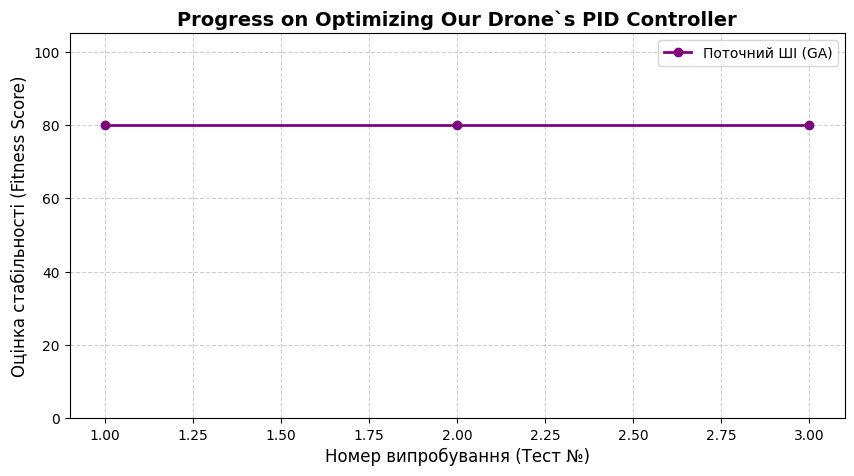

In [ ]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# 1. Залізобетонний шлях до твоєї бази даних
real_db_path = r"c:\Users\Gidroid\Desktop\AI_proj\data\processed\experiments.db"

# 2. Підключаємося до бази
conn = sqlite3.connect(real_db_path)

try:
    # 3. Витягуємо історію експериментів зі СПРАВЖНЬОЇ таблиці 'test_results'
    query = "SELECT id, timestamp, fitness_score, kp, ki, kd FROM test_results ORDER BY id"
    df_res = pd.read_sql_query(query, conn)
    
    print(f" Успішно знайдено записів у таблиці: {len(df_res)}")
    print(df_res) # Виведемо табличку на екран, щоб побачити цифри
    
    # 4. БУДУЄМО ГРАФІК ПРОГРЕСУ ОПТИМІЗАЦІЇ
    plt.figure(figsize=(10, 5))
    plt.plot(df_res['id'], df_res['fitness_score'], marker='o', linestyle='-', color='purple', linewidth=2, label='Поточний ШІ (GA)')

    # Оформлення графіка
    plt.title('Progress on Optimizing Our Drone`s PID Controller', fontsize=14, fontweight='bold')
    plt.xlabel('Номер випробування (Тест №)', fontsize=12)
    plt.ylabel('Оцінка стабільності (Fitness Score)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.ylim(0, 105) # Шкала від 0 до 100+ балів
    plt.legend()

    # Вмикаємо відображення
    plt.show()

except Exception as e:
    print(f"❌ Помилка: {e}")

finally:
    conn.close()